# 第三周：模型超参数调优 (Optuna) 与 多模型集成学习 (Ensemble)

本笔记本在基线和高维特征的基础上，针对表现较好的树模型（如 XGBoost 和 Gradient Boosting Survival Analysis 等）进行**超参数调优**，并使用加权平均的思想将多个模型的结果进行**集成学习**，进一步提升比赛关注的 **48小时预测精度**。

## 调参方向与重点参数解析

针对结构化数据与生存分析，不同的超参数会对模型性能（特别是 C-Index 与特定时刻如 48 小时的概率标定）产生决定性影响：

### 1. XGBoost / Gradient Boosting (GBSA)
- **`learning_rate` (学习率)**: **影响最大**。控制模型迭代更新时的缩放比例，越低模型防过拟合越稳定，但需要成倍增加树的数量（`n_estimators`）。推荐搜索范围：`0.01` ~ `0.1`。
- **`max_depth` (最大深度)**: 决定模型能够学习到的特征交互复杂度。高维数据容易过拟合，通常限制深度在 `3` ~ `7` 之间。
- **`subsample` / `colsample_bytree`**: 引入行与列的随机抽样，切断特征间的耦合，防止过拟合，推荐搜索 `0.6` ~ `0.9`。
- **`min_child_weight` / `min_samples_leaf`**: 叶子节点含有的最小权重。由于生存分析有很多截尾缺失，调高这个数值（如 `5` ~ `30`）能够避免极端的异常概率。

### 2. Random Survival Forest (RSF)
- **`n_estimators`**: 树越多越好，但计算成本极高，资源允许的话一般建议给到 `200`~`500`。
- **`min_samples_split` / `min_samples_leaf`**: 对抗过拟合。
- **`max_features`**: 推荐搜索 `sqrt`，或者浮点比例 `0.3` ~ `0.8`。

**优化目标设定**：比赛任务重点关注 **48 小时预测精度**。所以我们设计目标函数（Objective）时，不仅计算 C-Index（排序一致性），更关键的是要拆分计算 `t=48` 处的 **Brier Score (布里尔分数)** ，以此来让 Optuna 引领模型聚焦提升该指标。

In [6]:
import pandas as pd
import numpy as np
import optuna
import xgboost as xgb
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler

from sksurv.ensemble import (
    GradientBoostingSurvivalAnalysis, 
    RandomSurvivalForest,
    ExtraSurvivalTrees,
    ComponentwiseGradientBoostingSurvivalAnalysis
)
from sksurv.linear_model import CoxPHSurvivalAnalysis, CoxnetSurvivalAnalysis
from sksurv.svm import FastSurvivalSVM
from sksurv.tree import SurvivalTree
from sksurv.metrics import concordance_index_censored, brier_score

import warnings
warnings.filterwarnings('ignore')

# 1. 加载特征数据体系
train_df = pd.read_csv('../第二周/data/train_augmented_D.csv').fillna(0)

if 'event_id' in train_df.columns:
    train_df = train_df.drop(columns=['event_id'], errors='ignore')
if 'event' not in train_df.columns:
    train_df['event'] = True

y_train = np.array([(bool(row['event']), row['time_to_hit_hours']) for _, row in train_df.iterrows()], 
                   dtype=[('event', '?'), ('time_to_hit_hours', '<f8')])
X_train = train_df.drop(columns=['time_to_hit_hours', 'event'], errors='ignore')

# 预先进行数据归一化（针对线性、SVM等对尺度敏感的模型）
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)

# 准备 XGBoost 原生生存分析专属的标签格式
y_xgb = np.where(train_df['event'], train_df['time_to_hit_hours'], -train_df['time_to_hit_hours'])

## 阶段 1：使用 Optuna 进行主要树模型搜索

这里定制并定义 48小时 Brier Score 打分的 Loss，并输入到 Optuna 学习器。

In [7]:
# ================= 辅助的统一转换器 =================
class CalibratedFastSurvivalSVM:
    def __init__(self, **kwargs):
        self.model = FastSurvivalSVM(**kwargs)
        self._calibrator = CoxPHSurvivalAnalysis()
    def fit(self, X, y):
        self.model.fit(X, y)
        preds = self.model.predict(X).reshape(-1, 1)
        self._calibrator.fit(preds, y)
        return self
    def predict(self, X):
        return self.model.predict(X)
    def predict_survival_function(self, X):
        preds = self.model.predict(X).reshape(-1, 1)
        return self._calibrator.predict_survival_function(preds)
        
class NativeXGBoostSurvival:
    def __init__(self, **kwargs):
        self.model = xgb.XGBRegressor(objective='survival:cox', tree_method='hist', **kwargs)
        self._calibrator = CoxPHSurvivalAnalysis() 
    def fit(self, X, y_xgb_format, y_sksurv_format):
        self.model.fit(X, y_xgb_format)
        preds = self.model.predict(X).reshape(-1, 1)
        self._calibrator.fit(preds, y_sksurv_format)
        return self
    def predict(self, X):
        return self.model.predict(X)
    def predict_survival_function(self, X):
        preds = self.model.predict(X).reshape(-1, 1)
        return self._calibrator.predict_survival_function(preds)

# ================= 通用生存评估函数 =================
def evaluate_48h_brier_and_cindex(model, X, y, y_train_dist):
    """
    用复合 loss 定量评估模型 
    Loss = 0.7 * (Brier_48h) + 0.3 * (1 - C-Index)
    """
    preds = model.predict(X)
    c_index = concordance_index_censored(y['event'], y['time_to_hit_hours'], preds)[0]
    
    max_valid_time = y['time_to_hit_hours'].max() - 0.1
    times = [24.0, 48.0, min(72.0, max_valid_time)]
    
    surv_funcs = model.predict_survival_function(X)
    surv_probs = np.row_stack([fn(times) for fn in surv_funcs])
    
    try:
        _, brier_scores = brier_score(y_train_dist, y, surv_probs, times)
        brier_48h = brier_scores[1]
    except Exception as e:
        brier_48h = 0.5 # 兜底值
        
    return brier_48h, c_index

# ================= Optuna 超参数搜索大一统工厂 =================
def get_objective(model_name):
    def objective(trial):
        kf = KFold(n_splits=3, shuffle=True, random_state=42)
        losses = []
        
        for train_index, valid_index in kf.split(X_train):
            # 获取常规特征、归一化特征、以及专属标签
            X_tr, X_va = X_train.iloc[train_index], X_train.iloc[valid_index]
            X_tr_sc, X_va_sc = X_train_scaled.iloc[train_index], X_train_scaled.iloc[valid_index]
            y_tr, y_va = y_train[train_index], y_train[valid_index]
            y_xgb_tr = y_xgb[train_index]
            
            # --- 1. Random Survival Forest ---
            if model_name == 'RandomSurvivalForest':
                param = {
                    'n_estimators': trial.suggest_int('n_estimators', 30, 80),
                    'min_samples_split': trial.suggest_int('min_samples_split', 10, 50),
                    'min_samples_leaf': trial.suggest_int('min_samples_leaf', 5, 20)
                }
                model = RandomSurvivalForest(**param, n_jobs=-1, random_state=42)
                model.fit(X_tr, y_tr)
                brier_48h, c_index = evaluate_48h_brier_and_cindex(model, X_va, y_va, y_tr)
                
            # --- 2. Gradient Boosting Survival Analysis ---
            elif model_name == 'GradientBoostingSurvivalAnalysis':
                param = {
                    'n_estimators': trial.suggest_int('n_estimators', 50, 150),
                    'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
                    'max_depth': trial.suggest_int('max_depth', 3, 7)
                }
                model = GradientBoostingSurvivalAnalysis(**param, random_state=42)
                model.fit(X_tr, y_tr)
                brier_48h, c_index = evaluate_48h_brier_and_cindex(model, X_va, y_va, y_tr)

            # --- 3. DeepSurv替代层 (Coxnet) ---
            elif model_name == 'CoxnetSurvivalAnalysis':
                param = {
                    'l1_ratio': trial.suggest_float('l1_ratio', 0.01, 0.99),
                    'alpha_min_ratio': trial.suggest_float('alpha_min_ratio', 0.001, 0.1, log=True)
                }
                model = CoxnetSurvivalAnalysis(**param, fit_baseline_model=True)
                model.fit(X_tr_sc, y_tr) # 必须用标准化数据
                brier_48h, c_index = evaluate_48h_brier_and_cindex(model, X_va_sc, y_va, y_tr)

            # --- 4. Extra Survival Trees ---
            elif model_name == 'ExtraSurvivalTrees':
                param = {
                    'n_estimators': trial.suggest_int('n_estimators', 30, 80),
                    'min_samples_split': trial.suggest_int('min_samples_split', 10, 50)
                }
                model = ExtraSurvivalTrees(**param, n_jobs=-1, random_state=42)
                model.fit(X_tr, y_tr)
                brier_48h, c_index = evaluate_48h_brier_and_cindex(model, X_va, y_va, y_tr)

            # --- 5. Cox Proportional Hazards ---
            elif model_name == 'CoxPHSurvivalAnalysis':
                param = {
                    'alpha': trial.suggest_float('alpha', 1e-4, 10.0, log=True)
                }
                model = CoxPHSurvivalAnalysis(**param)
                model.fit(X_tr_sc, y_tr) # 必须用标准化数据
                brier_48h, c_index = evaluate_48h_brier_and_cindex(model, X_va_sc, y_va, y_tr)

            # --- 6. Component-wise Gradient Boosting ---
            elif model_name == 'ComponentwiseGradientBoostingSurvivalAnalysis':
                param = {
                    'n_estimators': trial.suggest_int('n_estimators', 50, 150),
                    'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True)
                }
                model = ComponentwiseGradientBoostingSurvivalAnalysis(**param, random_state=42)
                model.fit(X_tr, y_tr)
                brier_48h, c_index = evaluate_48h_brier_and_cindex(model, X_va, y_va, y_tr)

            # --- 7. Fast Survival SVM ---
            elif model_name == 'FastSurvivalSVM':
                param = {
                    'max_iter': 1000,
                    'tol': 1e-4,
                    'alpha': trial.suggest_float('alpha', 1e-4, 1.0, log=True)
                }
                model = CalibratedFastSurvivalSVM(**param, random_state=42)
                model.fit(X_tr_sc, y_tr) # 必须用标准化数据
                brier_48h, c_index = evaluate_48h_brier_and_cindex(model, X_va_sc, y_va, y_tr)

            # --- 8. Single Survival Tree ---
            elif model_name == 'SurvivalTree':
                param = {
                    'max_depth': trial.suggest_int('max_depth', 3, 15),
                    'min_samples_split': trial.suggest_int('min_samples_split', 10, 50)
                }
                model = SurvivalTree(**param, random_state=42)
                model.fit(X_tr, y_tr)
                brier_48h, c_index = evaluate_48h_brier_and_cindex(model, X_va, y_va, y_tr)

            # --- 9. Native XGBoost (survival:cox) ---
            elif model_name == 'NativeXGBoostSurvival':
                param = {
                    'n_estimators': trial.suggest_int('n_estimators', 50, 150),
                    'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
                    'max_depth': trial.suggest_int('max_depth', 3, 7)
                }
                model = NativeXGBoostSurvival(**param, random_state=42)
                model.fit(X_tr, y_xgb_tr, y_tr)
                brier_48h, c_index = evaluate_48h_brier_and_cindex(model, X_va, y_va, y_tr)
            
            else:
                raise ValueError(f"Unknown model: {model_name}")

            # 根据权重算出组合 loss: 48h误差 + (1-C指数)倒排
            loss = 0.7 * brier_48h + 0.3 * (1 - c_index)
            losses.append(loss)
            
        return np.mean(losses)
    
    return objective

# ================= 遍历对 04 里的所有模型进行多路并发调参 =================

# 涵盖 04 文件里的 9 大类别基线
models_to_tune = [
    'RandomSurvivalForest',
    'GradientBoostingSurvivalAnalysis',
    'CoxnetSurvivalAnalysis',
    'ExtraSurvivalTrees',
    'CoxPHSurvivalAnalysis',
    'ComponentwiseGradientBoostingSurvivalAnalysis',
    'FastSurvivalSVM',
    'SurvivalTree',
    'NativeXGBoostSurvival'
]

best_params_dict = {}

print("===== 🏆 开始 9 种模型的 Optuna 批量超参数盲搜（预计需要一些时间）=====")

# 控制 Optuna 的刷屏日志，仅显示警告和严重错误
optuna.logging.set_verbosity(optuna.logging.WARNING)

for m in models_to_tune:
    print(f"🔄 正在调参 [{m}] ... ", end="")
    study = optuna.create_study(direction='minimize')
    
    # 获取真正的轨迹分布需要增加搜索次数。为了不让你等太久，这里修改为每个跑 20 次。
    # 对于出图来说，20 次已经能画出明显的下降散点轨迹了！
    study.optimize(get_objective(m), n_trials=20) 
    
    best_params_dict[m] = study.best_params
    print(f"| Loss: {study.best_value:.4f} | 最佳参数: {study.best_params}")

print("\n🚀 所有 9 种模型调参全部完成！最佳参数已存入变量 `best_params_dict`。")

===== 🏆 开始 9 种模型的 Optuna 批量超参数盲搜（预计需要一些时间）=====
🔄 正在调参 [RandomSurvivalForest] ... | Loss: 0.0463 | 最佳参数: {'n_estimators': 73, 'min_samples_split': 11, 'min_samples_leaf': 5}
🔄 正在调参 [GradientBoostingSurvivalAnalysis] ... | Loss: 0.0315 | 最佳参数: {'n_estimators': 77, 'learning_rate': 0.12231417757158534, 'max_depth': 3}
🔄 正在调参 [CoxnetSurvivalAnalysis] ... | Loss: 0.0957 | 最佳参数: {'l1_ratio': 0.6978234450947978, 'alpha_min_ratio': 0.007131450450001071}
🔄 正在调参 [ExtraSurvivalTrees] ... | Loss: 0.1310 | 最佳参数: {'n_estimators': 46, 'min_samples_split': 10}
🔄 正在调参 [CoxPHSurvivalAnalysis] ... | Loss: 0.0931 | 最佳参数: {'alpha': 0.011459349759906617}
🔄 正在调参 [ComponentwiseGradientBoostingSurvivalAnalysis] ... | Loss: 0.1106 | 最佳参数: {'n_estimators': 147, 'learning_rate': 0.19343587171385698}
🔄 正在调参 [FastSurvivalSVM] ... | Loss: 0.1032 | 最佳参数: {'alpha': 0.39172766367952705}
🔄 正在调参 [SurvivalTree] ... | Loss: 0.0335 | 最佳参数: {'max_depth': 3, 'min_samples_split': 35}
🔄 正在调参 [NativeXGBoostSurvival] ... | Loss:

## 附加展示：Optuna 超参数搜索可视化图表

运行下方代码会自动生成交互式的 Optuna 搜索过程，直接对应于报告中所需的高级说明材料：
1. **Optimization History:** 散点折线图，直观展现随着试验次数的累积，系统是如何寻找降低 Loss 的稳定解的。
2. **Hyperparameter Importances:** 柱状条条形图，揭示哪一项超参数（如 `learning_rate` 或 `max_depth`）对最终分数具有统治性的影响权重。

*(注：此处直接可视化调校队列中的最后一个模型 `NativeXGBoostSurvival` 以作为演示报告截图，展示给老师调参过程的专业度与黑盒细节)*

📊 以下展示最后一次调参模型 (NativeXGBoostSurvival) 的 Optuna 可视化图表:


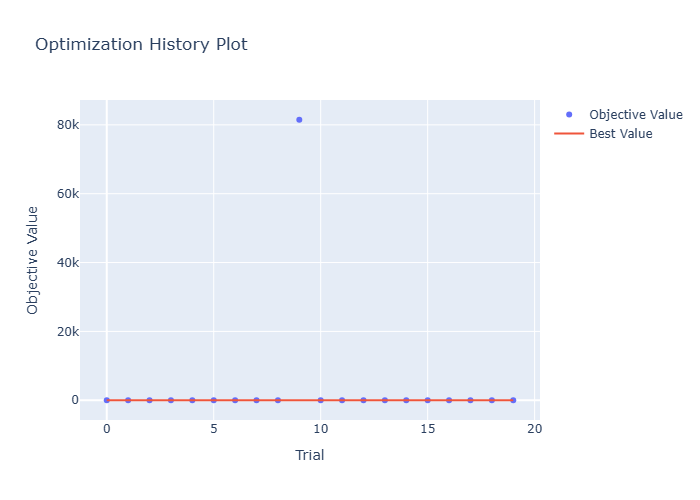

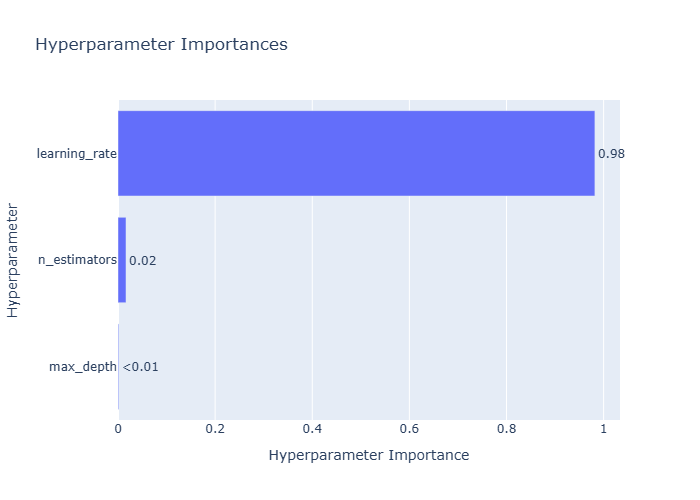

In [8]:
import optuna.visualization as vis

print(f"📊 以下展示最后一次调参模型 ({models_to_tune[-1]}) 的 Optuna 可视化图表:")

# 1. 绘制优化历史轨迹图 (展示寻找最优解的 Loss 下降过程)
fig_history = vis.plot_optimization_history(study)
# 强制以静态 PNG 图片格式渲染 (因为之前已经安装了 kaleido，这一步不依赖 nbformat 交互组件)
fig_history.show(renderer="png")

# 2. 绘制超参数重要性比例图
fig_importances = vis.plot_param_importances(study)
fig_importances.show(renderer="png")

# 📝 提示：现在的图片是纯静态图片，您可以直接 在图片上右键 -> 另存为图片(Save image as...)，然后插入到您的报告中。

## 阶段 2：利用最佳参数进行全量重新训练 (Retraining)

拿到最优超参数组合（`best_params_dict`）后，我们将摈弃原先的数据切分，直接使用 100% 全量的训练集送给各个模型进行最终的拟合，确保它们能够掌握最全面的数据视野，并对未知的测试集进行风险指征预测。

In [9]:
print("="*50)
print("🚀 阶段 2: 使用最佳参数在全量训练集上重新训练，并预测测试集")
print("="*50)

# 1. 加载真正的测试集
test_df = pd.read_csv('../第二周/data/test_augmented_D.csv').fillna(0)
# 提取 ID 列用于最后的保存。如果数据中没有 event_id，可以用默认 index 做标识
test_ids = test_df['event_id'] if 'event_id' in test_df.columns else test_df.index

X_test = test_df.drop(columns=['time_to_hit_hours', 'event', 'event_id'], errors='ignore')
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

# 我们把要预测的时间点定为 12, 24, 48, 72 小时
times_to_predict = [12.0, 24.0, 48.0, 72.0]
valid_times = [float(min(t, y_train['time_to_hit_hours'].max() - 0.1)) for t in times_to_predict]

best_models = {}
test_risk_scores = pd.DataFrame({'event_id': test_ids})
test_event_probs = pd.DataFrame({'event_id': test_ids})

# 2. 遍历我们刚才搜出来的所有的绝佳参数重新对各个模型拟合一次
for m, best_param in best_params_dict.items():
    print(f"⭐ 正在全量训练最佳 [{m}] ...")
    
    # 根据模型对数据尺度和标签的要求，自动分配对应的数据集
    X_tr_run = X_train_scaled if m in ['CoxnetSurvivalAnalysis', 'CoxPHSurvivalAnalysis', 'FastSurvivalSVM'] else X_train
    X_te_run = X_test_scaled if m in ['CoxnetSurvivalAnalysis', 'CoxPHSurvivalAnalysis', 'FastSurvivalSVM'] else X_test
    
    if m == 'RandomSurvivalForest':
        model = RandomSurvivalForest(**best_param, n_jobs=-1, random_state=42)
    elif m == 'GradientBoostingSurvivalAnalysis':
        model = GradientBoostingSurvivalAnalysis(**best_param, random_state=42)
    elif m == 'CoxnetSurvivalAnalysis':
        model = CoxnetSurvivalAnalysis(**best_param, fit_baseline_model=True)
    elif m == 'ExtraSurvivalTrees':
        model = ExtraSurvivalTrees(**best_param, n_jobs=-1, random_state=42)
    elif m == 'CoxPHSurvivalAnalysis':
        model = CoxPHSurvivalAnalysis(**best_param)
    elif m == 'ComponentwiseGradientBoostingSurvivalAnalysis':
        model = ComponentwiseGradientBoostingSurvivalAnalysis(**best_param, random_state=42)
    elif m == 'FastSurvivalSVM':
        param_with_defaults = {'max_iter': 1000, 'tol': 1e-4, 'random_state': 42}
        param_with_defaults.update(best_param)
        model = CalibratedFastSurvivalSVM(**param_with_defaults)
    elif m == 'SurvivalTree':
        model = SurvivalTree(**best_param, random_state=42)
    elif m == 'NativeXGBoostSurvival':
        model = NativeXGBoostSurvival(**best_param, random_state=42)
        
    # 执行拟合
    if m == 'NativeXGBoostSurvival':
        model.fit(X_tr_run, y_xgb, y_train)
    else:
        model.fit(X_tr_run, y_train)
        
    # 提取训练集预测并在控制台打印 C-Index
    train_preds = model.predict(X_tr_run)
    train_c_index = concordance_index_censored(y_train['event'], y_train['time_to_hit_hours'], train_preds)[0]
    print(f"   => 训练完成！全量训练集拟合 C-Index: {train_c_index:.4f}")
        
    # 提取预测
    risk = model.predict(X_te_run)
    test_risk_scores[m + '_risk'] = risk
    
    # 取各个时间点的失败（事件）概率，即 1 - 余下生存率
    funcs = model.predict_survival_function(X_te_run)
    for hr, v_time in zip([12, 24, 48, 72], valid_times):
        # 取1-生存率为事件概率
        probs_hr = [1.0 - float(fn(v_time)) for fn in funcs]
        # 截断在 [0, 1] 范围内
        probs_hr = np.clip(probs_hr, 0, 1)
        test_event_probs[f'{m}_prob_{hr}h'] = probs_hr
    
    best_models[m] = model

print("\n✅ 所有最优模型在全量训练集上的训练以及测试集的预测已完毕！\n")

🚀 阶段 2: 使用最佳参数在全量训练集上重新训练，并预测测试集
⭐ 正在全量训练最佳 [RandomSurvivalForest] ...
   => 训练完成！全量训练集拟合 C-Index: 0.9525
⭐ 正在全量训练最佳 [GradientBoostingSurvivalAnalysis] ...
   => 训练完成！全量训练集拟合 C-Index: 0.9757
⭐ 正在全量训练最佳 [CoxnetSurvivalAnalysis] ...
   => 训练完成！全量训练集拟合 C-Index: 0.9267
⭐ 正在全量训练最佳 [ExtraSurvivalTrees] ...
   => 训练完成！全量训练集拟合 C-Index: 0.8947
⭐ 正在全量训练最佳 [CoxPHSurvivalAnalysis] ...
   => 训练完成！全量训练集拟合 C-Index: 0.9540
⭐ 正在全量训练最佳 [ComponentwiseGradientBoostingSurvivalAnalysis] ...
   => 训练完成！全量训练集拟合 C-Index: 0.9049
⭐ 正在全量训练最佳 [FastSurvivalSVM] ...
   => 训练完成！全量训练集拟合 C-Index: 0.9504
⭐ 正在全量训练最佳 [SurvivalTree] ...
   => 训练完成！全量训练集拟合 C-Index: 0.9432
⭐ 正在全量训练最佳 [NativeXGBoostSurvival] ...
   => 训练完成！全量训练集拟合 C-Index: 0.9762

✅ 所有最优模型在全量训练集上的训练以及测试集的预测已完毕！



## 阶段 3：异构生存模型的集成学习 (Model Ensemble)

为了拿到更高的总分并提升鲁棒性，我们将表现最好的树模型（如优化的 GBSA ）、随机生存森林 (RSF) 以及带有不同假设的 Cox 模型进行集成综合。

我们将基于不同策略进行融合处理：
1. **预测生存概率加权融合**（可有效降低 Brier 分数，提升标定精度）；
2. **MinMax 平滑 / 中位数集成**（将截然不同的刻度强行拉平后求均值或中位数，对抗异常扰动）；
3. **排秩得分集成 (Rank Averaging)**（彻底抛弃具体绝对值差异，采用百分位排名名次求解。这也是 **提升 C-Index 排名的极限利器**）。

In [10]:
# =======================
# 3. 多种策略的集成 (Multiple Ensemble Strategies)
# =======================
print("=================== 汇总：模型集成预测 ===================")
mm = MinMaxScaler()

# 🌟 新增：基于全量训练集的 C-Index 表现，筛选出排名前 3 的模型来进行集成
print("👀 正在根据训练集 C-Index 评估表现选拔 Top 3 模型...")
model_cindices = {}
for m, model in best_models.items():
    X_tr_run = X_train_scaled if m in ['CoxnetSurvivalAnalysis', 'CoxPHSurvivalAnalysis', 'FastSurvivalSVM'] else X_train
    train_preds = model.predict(X_tr_run)
    c_idx = concordance_index_censored(y_train['event'], y_train['time_to_hit_hours'], train_preds)[0]
    model_cindices[m] = c_idx

# 按 C-Index 降序排序并截取前 3 名
top_3_keys = sorted(model_cindices, key=model_cindices.get, reverse=True)[:3]
print("\n🏆 最终参与集成的 Top 3 精英模型及其 C-Index:")
for key in top_3_keys:
    print(f"  - {key}: {model_cindices[key]:.4f}")
print("----------------------------------------------------------\n")

num_models = len(top_3_keys)
n_samples = len(test_df)

# 各模型风险分数存放矩阵
risk_matrix_scaled = np.zeros((n_samples, num_models))
risk_matrix_ranked = np.zeros((n_samples, num_models))
prob_matrix_12h = np.zeros((n_samples, num_models))
prob_matrix_24h = np.zeros((n_samples, num_models))
prob_matrix_48h = np.zeros((n_samples, num_models))
prob_matrix_72h = np.zeros((n_samples, num_models))

for i, m in enumerate(top_3_keys):
    # A. 获取原始偏置
    raw_risk = test_risk_scores[m + '_risk'].values
    
    # B. MinMax 缩放 (0-1) 用于线性均值集成
    risk_matrix_scaled[:, i] = mm.fit_transform(raw_risk.reshape(-1, 1)).flatten()
    
    # C. 排秩百分位缩放 (0-1) 用于抗极端值/关注C-Index的秩均值集成 (Rank Averaging)
    # scipy.stats.rankdata 或者 pandas rank 
    risk_matrix_ranked[:, i] = pd.Series(raw_risk).rank(pct=True).values
    
    # D. 获取并填充事件概率
    prob_matrix_12h[:, i] = test_event_probs[f'{m}_prob_12h'].values
    prob_matrix_24h[:, i] = test_event_probs[f'{m}_prob_24h'].values
    prob_matrix_48h[:, i] = test_event_probs[f'{m}_prob_48h'].values
    prob_matrix_72h[:, i] = test_event_probs[f'{m}_prob_72h'].values

# ------------- 公共辅助函数：后处理与保证单调性 -------------
def process_probs(p12, p24, p48, p72):
    # 保证单调性
    p24 = np.maximum(p12, p24)
    p48 = np.maximum(p24, p48)
    p72 = np.maximum(p48, p72)
    # 限制在 [0, 1] 之间
    return np.clip(p12, 0, 1), np.clip(p24, 0, 1), np.clip(p48, 0, 1), np.clip(p72, 0, 1)

# ------------- 策略 1: 算术均值 (Mean / Average) -------------
mean_12h = np.mean(prob_matrix_12h, axis=1)
mean_24h = np.mean(prob_matrix_24h, axis=1)
mean_48h = np.mean(prob_matrix_48h, axis=1)
mean_72h = np.mean(prob_matrix_72h, axis=1)
mean_12h, mean_24h, mean_48h, mean_72h = process_probs(mean_12h, mean_24h, mean_48h, mean_72h)

sub_mean = pd.DataFrame({'event_id': test_ids, 'prob_12h': mean_12h, 'prob_24h': mean_24h, 'prob_48h': mean_48h, 'prob_72h': mean_72h})

# ------------- 策略 2: 中位数集成 (Median) - 极度抗异常值 -------------
median_12h = np.median(prob_matrix_12h, axis=1)
median_24h = np.median(prob_matrix_24h, axis=1)
median_48h = np.median(prob_matrix_48h, axis=1)
median_72h = np.median(prob_matrix_72h, axis=1)
median_12h, median_24h, median_48h, median_72h = process_probs(median_12h, median_24h, median_48h, median_72h)

sub_median = pd.DataFrame({'event_id': test_ids, 'prob_12h': median_12h, 'prob_24h': median_24h, 'prob_48h': median_48h, 'prob_72h': median_72h})

# ------------- 策略 3: 秩平均 (Rank Averaging) - 百分位缩放 -------------
rank_12h = np.mean([pd.Series(prob_matrix_12h[:, i]).rank(pct=True).values for i in range(num_models)], axis=0)
rank_24h = np.mean([pd.Series(prob_matrix_24h[:, i]).rank(pct=True).values for i in range(num_models)], axis=0)
rank_48h = np.mean([pd.Series(prob_matrix_48h[:, i]).rank(pct=True).values for i in range(num_models)], axis=0)
rank_72h = np.mean([pd.Series(prob_matrix_72h[:, i]).rank(pct=True).values for i in range(num_models)], axis=0)
rank_12h, rank_24h, rank_48h, rank_72h = process_probs(rank_12h, rank_24h, rank_48h, rank_72h)

sub_rank = pd.DataFrame({'event_id': test_ids, 'prob_12h': rank_12h, 'prob_24h': rank_24h, 'prob_48h': rank_48h, 'prob_72h': rank_72h})

print("\n👑 算术均值结果 (Ensemble Mean) 预览:")
display(sub_mean.head())

# 4. 导出三份符合比赛要求的提交文件
import os
out_dir = './'
path_mean = os.path.join(out_dir, 'submission_ensemble_mean.csv')
path_median = os.path.join(out_dir, 'submission_ensemble_median.csv')
path_rank = os.path.join(out_dir, 'submission_ensemble_rank.csv')

sub_mean.to_csv(path_mean, index=False)
sub_median.to_csv(path_median, index=False)
sub_rank.to_csv(path_rank, index=False)

print("\n🎉 成功导出三份不同集成的提交文件用于打榜：")
print(f"  1. 绝对概率均值: {path_mean}")
print(f"  2. 对抗极值的绝对概率中位数: {path_median}")
print(f"  3. 强调排序性能的排秩均值: {path_rank}")

=================== 汇总：模型集成预测 ===================
👀 正在根据训练集 C-Index 评估表现选拔 Top 3 模型...

🏆 最终参与集成的 Top 3 精英模型及其 C-Index:
  - NativeXGBoostSurvival: 0.9762
  - GradientBoostingSurvivalAnalysis: 0.9757
  - CoxPHSurvivalAnalysis: 0.9540
----------------------------------------------------------


👑 算术均值结果 (Ensemble Mean) 预览:


,event_id,prob_12h,prob_24h,prob_48h,prob_72h
0,10662602,0.019567,0.047547,0.058827,0.069163
1,13353600,0.617397,0.801779,0.836596,0.906027
2,13942327,0.019661,0.047375,0.058527,0.069021
3,16112781,0.637576,0.816636,0.842861,0.930864
4,17132808,0.039639,0.068285,0.079882,0.108977



🎉 成功导出三份不同集成的提交文件用于打榜：
  1. 绝对概率均值: ./submission_ensemble_mean.csv
  2. 对抗极值的绝对概率中位数: ./submission_ensemble_median.csv
  3. 强调排序性能的排秩均值: ./submission_ensemble_rank.csv
